# Sales Forecasting 

## Internship Final Project 

### Imports 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Task 1 -  Data Loading, Merging & Deep Exploration


### Loading Dataset

In [2]:
sales_df = pd.read_csv("train.csv")
games_df = pd.read_csv("vgsales.csv")

In [3]:
sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Check shape 

In [5]:
sales_df.shape

(9800, 18)

### Check Data types

In [9]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

### Parse Date Columns 

In [14]:
# Convert Date Columns into datetime format (DD/MM/YYYY)


sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"],format="%d/%m/%Y")
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"],format="%d/%m/%Y")

In [13]:
# Verify the updated data types

sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

### Time Feature Extraction 

In [15]:
# Extract time-based features from the Order Date
sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Week Number"] = sales_df["Order Date"].dt.isocalendar().week
sales_df["Day of Week"] = sales_df["Order Date"].dt.day_name()
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

In [16]:
sales_df['Order Date'].min(),sales_df['Order Date'].max()

(Timestamp('2015-01-03 00:00:00'), Timestamp('2018-12-30 00:00:00'))

### Season Feature

In [17]:
# Map each month to its corresponding season
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

sales_df["Season"] = sales_df["Month"].map(season_map)

### Data Quality Check

In [19]:
# check for missing values
sales_df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

### Observation 

Most of the columns do not contain any missing values. Only the 'Postal Code' column has 11 missing entries, while all other columns are complete.

In [20]:
# check for duplicate values
sales_df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset, indicating that each transaction is unique. This helps ensure that the analysis and forecasting results are not affected by repeated entries.

In [21]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

### Observation

After converting the date columns, all features have appropriate data types. No additional data type issues were found in the dataset apart from the previously identified missing values in the Postal Code column.


In [22]:
sales_df['Order Date'].duplicated().sum()

np.int64(8570)

### Daily , weekly and Monthly Sales Aggregation

In [23]:
# Aggregate total sales for each day
daily_sales = (
    sales_df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [ ]:
daily_sales.shape

(1230, 2)

In [25]:
# Aggregate daily sales into weekly totals
weekly_sales = (
    daily_sales.set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [27]:
# Aggregate daily sales into monthly totals
monthly_sales = (
    daily_sales.set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [28]:
sales_df['Category'].value_counts()

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

### Revenue Analysis by Product Category

In [29]:
# Calculate the total revenue generated by each product category
category_revenue = sales_df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_revenue.round(2)

Category
Technology         827455.87
Furniture          728658.58
Office Supplies    705422.33
Name: Sales, dtype: float64

### Observation :

The Technology category generated the highest total revenue, contributing approximately $827,455.87 in sales. Furniture ranked second, while Office Supplies generated the lowest total revenue among the three categories.

### Revenue Visualization

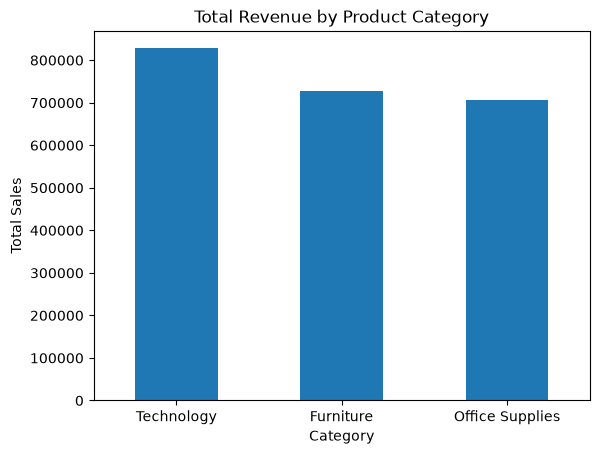

In [30]:
# Visualize total revenue by product category
category_revenue.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

### Sales Growth By Region

In [33]:
# Calculate yearly sales for each region
region_sales = sales_df.groupby(["Year", "Region"])["Sales"].sum().unstack()

region_sales

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


### Sales Growth Visualization

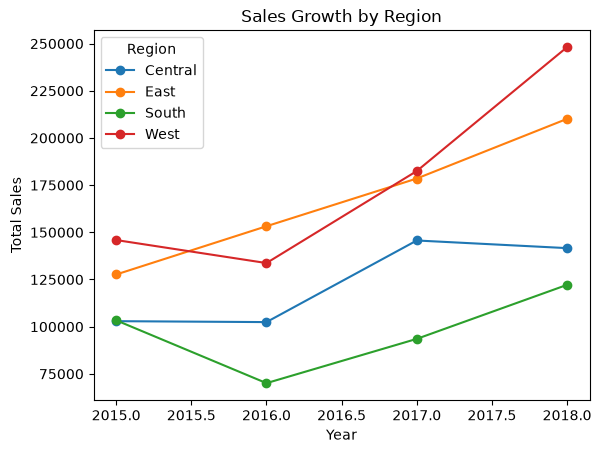

In [34]:
region_sales.plot(marker="o")

plt.title("Sales Growth by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend(title="Region")
plt.show()

### Observation : 
The East region showed the most consistent sales growth over the four-year period, with sales increasing steadily each year. Although the West region achieved the highest overall sales by 2018, it experienced a decline between 2015 and 2016, making its growth less consistent than the East region.

### Shipping Time Analysis by Region

In [35]:
# Calculate the shipping time (in days) for each order
sales_df["Shipping Time"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

sales_df[["Order Date", "Ship Date", "Shipping Time"]].head()

,Order Date,Ship Date,Shipping Time
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [36]:
# Calculate the average shipping time for each region
shipping_time_by_region = (
    sales_df.groupby("Region")["Shipping Time"]
    .mean()
    .sort_values()
)

shipping_time_by_region.round(2)

Region
East       3.91
West       3.93
South      3.96
Central    4.07
Name: Shipping Time, dtype: float64

### Observation : 
The average shipping time is approximately 4 days across all regions. Although the Central region has the highest average shipping time (4.07 days) and the East region has the lowest (3.91 days), the differences are minimal, indicating a fairly consistent shipping process across regions.

### Monthly Sales Seasonality Analysis

In [37]:
sales_df.groupby(['Year',"Month"])["Sales"].sum().unstack()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2015,14205.7070,4519.8920,55205.7970,27906.8550,23644.3030,34322.9356,33781.543,27117.5365,81623.5268,31453.3930,77907.6607,68167.0585
2016,18066.9576,11951.4110,32339.3184,34154.4685,29959.5305,23599.3740,28608.259,36818.3422,63133.6060,31011.7375,75249.3995,74543.6012
2017,18542.4910,22978.8150,51165.0590,38679.7670,56656.9080,39724.4860,38320.783,30542.2003,69193.3909,59583.0330,79066.4958,95739.1210
2018,43476.4740,19920.9974,58863.4128,35541.9101,43825.9822,48190.7277,44825.104,62837.8480,86152.8880,77448.1312,117938.1550,83030.3888


### Visualization

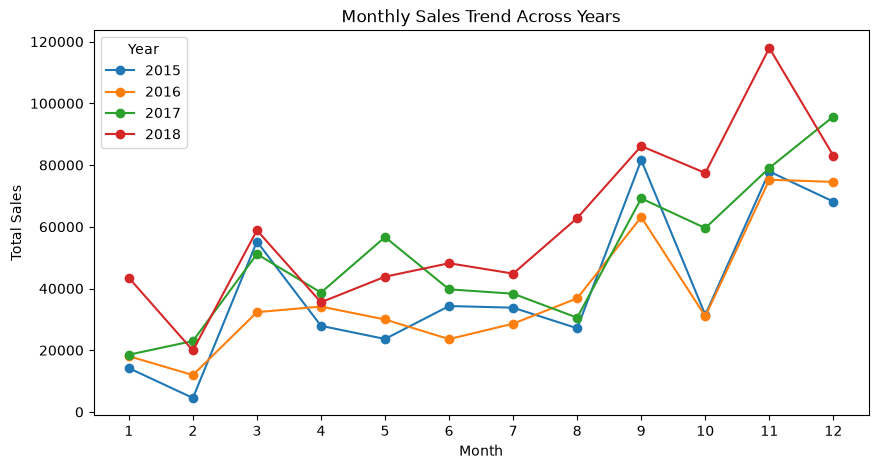

In [38]:
# Visualize monthly sales trends across different years
monthly_trend = sales_df.groupby(["Year", "Month"])["Sales"].sum().unstack()

monthly_trend.T.plot(figsize=(10, 5), marker="o")

plt.title("Monthly Sales Trend Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.show()

### Observation : 
The sales data shows a clear seasonal pattern across all four years. Sales consistently increase during September, November, and December, with November recording the highest sales in most years. In contrast, the beginning of the year, particularly January and February, generally experiences lower sales. This indicates strong year-end seasonal demand.

##  Task 1 Summary

- Successfully loaded and explored the Superstore Sales dataset.
- Performed feature engineering by extracting time-based features.
- Checked data quality, including missing values, duplicates, and data types.
- Aggregated sales into daily, weekly, and monthly levels.
- Identified Technology as the highest revenue-generating category.
- Found that the East region showed the most consistent sales growth.
- Observed that average shipping time remained close to 4 days across all regions.
- Detected clear seasonality, with sales peaking during September, November, and December.